# Task 3 follow-up: a single-model PINN distilled from the ensemble

The Constrained Deep Ensemble (`NN_Ensemble.ipynb`, `models/task3/ensemble_pinn.pt`)
is the most accurate surrogate in this study, but it is 5 networks: every
evaluation costs 5 forward passes and the checkpoint is a bundle of 5 state
dicts. The single-model PINN (`models/task3/pinn.pt`) is one clean network but
gives up accuracy. The reason a single trained network cannot catch the
ensemble is documented in the ensemble notebook: with 6400 training rows,
seed-to-seed training noise is larger than any architecture effect, and the
ensemble wins exactly because averaging removes that noise.

This notebook gets the ensemble's accuracy back into one network with
knowledge distillation (Hinton et al., 2015, arXiv:1503.02531): the frozen
ensemble acts as a teacher, labels as many synthetic operating points as we
want, and a single student network is trained on those labels plus the real
training rows. The student then gets three hard constraint layers: the same
`VaporSumToOneProjection` and `LiquidClosure` as the models it replaces, plus a
new `RecoveryClamp` (section 3b) that keeps the predicted methanol recovery
inside its physical bounds $[0, 1]$ and at exactly 0 on no-liquid rows.

Distillation changes the learning problem in our favor in two ways:

1. **No data limit.** The teacher can label any point in the input box, so the
   student trains on 150k points instead of 6400. The schema gives the exact
   box: each input is uniform in its range, and `T4` must stay at or below
   `T_flash - 2` (the real training data follows the same design, verified in
   the EDA). Sampling is therefore trivial and cannot leave the data
   distribution.
2. **A smooth, noise-free target.** The student fits the teacher's function,
   not noisy simulator rows, so the capacity/overfitting trade-off that forced
   `hidden=32` on the real data no longer binds. Bigger students are fair game
   and dropout is unnecessary.

All model selection uses validation data only (a held-out teacher-labelled
synthetic set; the real validation fold is shown for context). The held-out
test set is evaluated once, for the one selected model, in section 8.

### Conventions (identical to the other NN notebooks)
- 9 schema inputs, 15 modeled outputs; the 4 deterministic outputs (`T3`, `P3`,
  `P4`, `MeOH_purity_stream4`) are recovered by direct assignment.
- `x_H2_4` is trained in log-space; the 15-column target matrix is standardized.
- 80/20 train/val split stratified on `n4_total == 0`, `random_state=42`.
- The final model is saved to `models/task3/improved_pinn.pt`. No existing
  checkpoint is overwritten.

One deviation from the earlier notebooks: this notebook trains on the GPU when
one is available, because the distillation stage uses 150k synthetic rows. On a
CPU-only machine it still runs, just slower, and results can differ in the last
digits.

## 0. Install PyTorch (run once)

In [1]:
import subprocess, sys
for pkg in ["torch"]:
    try:
        __import__(pkg)
        print(f"{pkg} already installed")
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print("\n*** Restart the kernel before running the remaining cells. ***")

torch already installed


## 1. Imports and reproducibility

Everything comes from the shared `nn_utils.py` pipeline, as in the other NN
notebooks.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

import nn_utils as nu
from nn_utils import (
    INPUT_COLS, OUTPUT_COLS, MODEL_OUTPUT_COLS, RANDOM_STATE,
    VAPOR_FRACTION_COLS, LIQUID_FRACTION_COLS,
    load_data, build_scaled_split, TrainConfig, train_model,
    predict_raw, predict_scaled,
    regression_metrics_by_output, regime_diagnostics, assemble_full_prediction,
    parity_grid, VaporSumToOneProjection, LiquidClosure, RecoveryClamp,
    EnsembleModel, save_checkpoint,
)

nu.seed_everything(RANDOM_STATE)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | device: {device}")

torch 2.5.1+cu121 | device: cuda


## 2. Load data

In [3]:
data = load_data("dataset")
scaled = build_scaled_split(data, val_size=0.2, seed=RANDOM_STATE)

print(f"train fit {len(scaled.train_idx)} | val {len(scaled.val_idx)} | test {len(scaled.X_test_s)}")
print(f"no-liquid rows: train {data.no_liquid_train.sum()} | test {data.no_liquid_test.sum()}")

train fit 6400 | val 1600 | test 2000
no-liquid rows: train 13 | test 4


## 3. Model class and helpers

The backbone class is the RTDL-style pre-norm bottleneck Residual MLP, copied
verbatim from `NN_ResidualMLP.ipynb` (Gorishniy et al., NeurIPS 2021). It is
needed both to rebuild the ensemble members (the teacher) and as the student.
`wrap_pinn` attaches the two hard constraint layers exactly as in
`NN_PINN.ipynb`; it is used to rebuild the published models. The student uses
`wrap_pinn_bounded`, which adds the new recovery bounds layer introduced in
section 3b.

`val_raw_r2` computes the validation mean R2 in raw units, aggregated the same
way the study reports test performance. We use it as the context metric for
comparing models on the real validation fold: the scaled-space val MSE is not a
fair yardstick for constrained models, because the closure re-encodes the
log-scaled `x_H2_4` and a handful of rows near the regime gate dominate the
number.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, hidden, dropout, hidden_mult=2.0):
        super().__init__()
        dh = int(hidden * hidden_mult)
        self.norm = nn.LayerNorm(hidden); self.lin1 = nn.Linear(hidden, dh)
        self.act = nn.GELU(); self.drop1 = nn.Dropout(dropout)
        self.lin2 = nn.Linear(dh, hidden); self.drop2 = nn.Dropout(dropout * 0.5)
    def forward(self, x):
        r = x; x = self.norm(x); x = self.lin1(x); x = self.act(x)
        x = self.drop1(x); x = self.lin2(x); x = self.drop2(x); return x + r


class ResidualMLP(nn.Module):
    def __init__(self, in_dim=len(INPUT_COLS), out_dim=len(MODEL_OUTPUT_COLS),
                 hidden=64, n_blocks=4, dropout=0.20, hidden_mult=2.0):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([ResidualBlock(hidden, dropout, hidden_mult) for _ in range(n_blocks)])
        self.final_norm = nn.LayerNorm(hidden); self.head = nn.Linear(hidden, out_dim)
    def forward(self, x):
        x = self.input_proj(x)
        for b in self.blocks: x = b(x)
        return self.head(self.final_norm(x))


N4_THRESHOLD = 0.05


def wrap_pinn(backbone):
    # The 3-stage stack of the published models (pinn.pt, the ensemble).
    return nn.Sequential(
        backbone,
        VaporSumToOneProjection.from_transformer(scaled.Y_transformer),
        LiquidClosure.from_transformer(scaled.Y_transformer, n4_threshold=N4_THRESHOLD),
    )


def wrap_pinn_bounded(backbone):
    # The 4-stage stack of this notebook's model: the same two closure layers
    # plus the new hard recovery bounds (section 3b).
    return nn.Sequential(
        backbone,
        VaporSumToOneProjection.from_transformer(scaled.Y_transformer),
        LiquidClosure.from_transformer(scaled.Y_transformer, n4_threshold=N4_THRESHOLD),
        RecoveryClamp.from_transformer(scaled.Y_transformer, n4_threshold=N4_THRESHOLD),
    )


def val_raw_r2(model):
    pred = assemble_full_prediction(
        predict_raw(model, scaled.X_val_s, scaled.Y_transformer, device=device),
        data.X_train.iloc[scaled.val_idx])
    m = regression_metrics_by_output(data.y_train.iloc[scaled.val_idx], pred, OUTPUT_COLS)
    return float(m["R2"].mean(skipna=True))

### 3b. A new constraint layer: hard physical bounds on MeOH recovery

`MeOH_recovery` is a fraction (methanol leaving in stream 4 over methanol
produced in the reactor), so it can never be below 0 or above 1, and the schema
says it is exactly 0 when the flash produces no liquid. A regression backbone
is unbounded there, and the overshoot is not hypothetical: Task 4 measured
surrogate predictions slightly above 1 near the high-recovery corner and had
to cap recovery inside the optimizer. This notebook builds the bound into the
model instead, as a fourth hard layer, `RecoveryClamp` (added to
`nn_utils.py`):

$$\text{rec}_{new} = \text{gate}(n_4) \cdot \min(\max(\text{rec}, 0), 1)$$

with the same $n_{4,total} > 0.05$ regime gate as the liquid closure. Why a
hard clamp and not something smoother:

- The recovery column is affine-scaled (not log-scaled), so clamping in linear
  units is the exact L2 projection onto the $[0, 1]$ box in standardized space,
  the same KKT-hPINN idea as the vapor projection. A projection onto a convex
  set is non-expansive: the true value always lies inside the box, so the layer
  can only reduce the recovery error, never increase it.
- It is the identity wherever the prediction is already inside the bounds, so
  it can be attached post-hoc with no fine-tuning. (The liquid closure needed
  fine-tuning because renormalisation reshapes every liquid prediction; the
  clamp touches only the violating rows.)
- A sigmoid squashing head would change the function everywhere, need full
  retraining, and never reach exactly 0 or 1. A soft penalty in the loss
  guarantees nothing at inference. Both rejected.

The cell below verifies the layer on random standardized vectors before it is
used: bounds hold on gate-open rows, recovery is exactly 0 on gate-closed rows,
in-bounds predictions pass through unchanged, the other 14 outputs are
untouched, and gradients flow (needed for Task 4).

In [5]:
rc = RecoveryClamp.from_transformer(scaled.Y_transformer, n4_threshold=N4_THRESHOLD)
ri, ni = rc.rec_idx, rc.n4_idx

torch.manual_seed(0)
z = (torch.randn(4096, len(MODEL_OUTPUT_COLS)) * 3.0).requires_grad_(True)
out = rc(z)
lin = scaled.Y_transformer.inverse_transform(out.detach().numpy())
lin_in = scaled.Y_transformer.inverse_transform(z.detach().numpy())
rec, n4 = lin[:, ri], lin[:, ni]
gate = n4 > N4_THRESHOLD
in_bounds = gate & (lin_in[:, ri] >= 0) & (lin_in[:, ri] <= 1)
other_cols = [j for j in range(len(MODEL_OUTPUT_COLS)) if j != ri]

out.sum().backward()
grad_ok = bool(torch.isfinite(z.grad).all() and z.grad.abs().sum() > 0)

print("RecoveryClamp on 4096 random standardized vectors:")
print(f"  gate open   ({int(gate.sum())} rows): recovery in "
      f"[{rec[gate].min():.6f}, {rec[gate].max():.6f}]")
print(f"  gate closed ({int((~gate).sum())} rows): max |recovery| = {np.abs(rec[~gate]).max():.3e}")
print(f"  identity on in-bounds rows: max change = {np.abs(rec[in_bounds] - lin_in[in_bounds, ri]).max():.3e}")
print(f"  other outputs untouched: {bool((out.detach()[:, other_cols] == z.detach()[:, other_cols]).all())}")
print(f"  gradient flow finite and nonzero: {grad_ok}")

assert rec[gate].min() >= -1e-6 and rec[gate].max() <= 1.0 + 1e-6
assert np.abs(rec[~gate]).max() < 1e-6
assert np.abs(rec[in_bounds] - lin_in[in_bounds, ri]).max() < 1e-6 and grad_ok
print("\nAll RecoveryClamp claims hold.")

RecoveryClamp on 4096 random standardized vectors:
  gate open   (3340 rows): recovery in [-0.000000, 1.000000]
  gate closed (756 rows): max |recovery| = 5.960e-08
  identity on in-bounds rows: max change = 0.000e+00
  other outputs untouched: True
  gradient flow finite and nonzero: True

All RecoveryClamp claims hold.


## 4. The teacher

The teacher is the published Constrained Deep Ensemble, rebuilt from its
checkpoint and frozen. One design choice matters a lot:

**We distill the ensemble average BEFORE the closure layers.** The closed
teacher is discontinuous at its regime gate (`n4_total = 0.05`): near the gate,
the log-scaled `x_H2_4` target jumps by about 16 log units, and those few
synthetic points dominate an MSE on the closed outputs (we measured this; with
closed-teacher labels the student's held-out matching error plateaus about two
orders of magnitude higher). The pre-closure ensemble average is smooth, so the
student can match it almost exactly. The closure layers are attached to the
student afterwards. This is safe precisely because the ensemble members were
individually fine-tuned THROUGH the closure in `NN_Ensemble.ipynb`: their
average is already closure-adapted, so the student inherits that adaptation.
(Bolting the closure onto a non-adapted model is exactly the Strategy A failure
documented in the ensemble notebook.)

As a sanity check that we loaded the right thing, the closed teacher and the
published single PINN are scored on the real validation fold (validation only;
the test set stays sealed).

In [6]:
cke = torch.load("models/task3/ensemble_pinn.pt", map_location="cpu", weights_only=False)
members = []
for sd in cke["member_state_dicts"]:
    m = ResidualMLP(**cke["member_cfg"]); m.load_state_dict(sd); members.append(m)
teacher_raw = EnsembleModel(members).to(device)      # pre-closure: smooth
teacher_raw.eval()
for p in teacher_raw.parameters():
    p.requires_grad_(False)
teacher_closed = wrap_pinn(teacher_raw)

_ckp = torch.load("models/task3/pinn.pt", map_location="cpu", weights_only=False)
_exp = _ckp["extra"]
_bbp = ResidualMLP(in_dim=_exp["in_dim"], out_dim=_exp["out_dim"], hidden=_exp["hidden"],
                   n_blocks=_exp["n_blocks"], dropout=_exp["dropout"], hidden_mult=_exp["hidden_mult"])
pinn_published = wrap_pinn(_bbp)
pinn_published.load_state_dict(_ckp["model_state_dict"])

print(f"teacher (closed)   val raw R2 = {val_raw_r2(teacher_closed):.6f}")
print(f"published PINN     val raw R2 = {val_raw_r2(pinn_published):.6f}")

teacher (closed)   val raw R2 = 0.995622
published PINN     val raw R2 = 0.997867


## 5. Synthetic operating points

Uniform in the schema box, with the `T4 <= T_flash - 2` coupling. 150k points
for training, 10k held out for early stopping. The teacher labels both sets.

**Early stopping watches the held-out teacher-labelled set**, not the 1600-row
real validation fold: matching the teacher is the training goal, and this
signal is smooth and low-noise, so the optimizer is not misled by the handful
of hard rows that dominate the real fold's scaled MSE.

In [7]:
BOUNDS = {
    "n1_total": (800.0, 1600.0), "y_CO_1": (0.25, 0.45), "y_H2O_1": (0.0, 0.04),
    "n2_total": (0.0, 400.0), "T1": (290.0, 320.0), "T_reactor_in": (470.0, 540.0),
    "P_R": (50.0, 80.0), "T_flash": (290.0, 360.0), "T4": (280.0, 340.0),
}

def sample_inputs(n, seed):
    rng = np.random.default_rng(seed)
    X = pd.DataFrame({c: rng.uniform(lo, hi, n) for c, (lo, hi) in BOUNDS.items()})[INPUT_COLS]
    t4_hi = np.minimum(BOUNDS["T4"][1], X["T_flash"].values - 2.0)
    X["T4"] = BOUNDS["T4"][0] + rng.uniform(0.0, 1.0, n) * (t4_hi - BOUNDS["T4"][0])
    return X

def teacher_label(X_s):
    with torch.no_grad():
        chunks = []
        Xt = torch.as_tensor(X_s, dtype=torch.float32, device=device)
        for i in range(0, len(Xt), 16384):
            chunks.append(teacher_raw(Xt[i:i+16384]).cpu().numpy())
    return np.concatenate(chunks, axis=0)

N_TRAIN_SYNTH, N_VAL_SYNTH = 150000, 10000
X_tr_synth_s = scaled.X_scaler.transform(sample_inputs(N_TRAIN_SYNTH, seed=123).values)
X_va_synth_s = scaled.X_scaler.transform(sample_inputs(N_VAL_SYNTH, seed=456).values)
y_tr_synth_s = teacher_label(X_tr_synth_s)
y_va_synth_s = teacher_label(X_va_synth_s)
print(f"teacher labelled {N_TRAIN_SYNTH} train + {N_VAL_SYNTH} val synthetic points")

teacher labelled 150000 train + 10000 val synthetic points


## 6. Student variants

Four students, differing in capacity and in whether the real 6400 rows are
mixed in with their true labels (the standard practice of mixing hard and soft
targets, which anchors the student to the simulator where real data exists).
All train on the raw 9 inputs, like the teacher. Dropout 0 and weight decay
1e-5: the target function is smooth and noise-free, so regularisation only
slows the match. The student with the lowest held-out teacher-val MSE is
selected; the real-fold raw R2 is shown for context only.

In [8]:
#                 name          hidden blocks mix_real
D_VARIANTS = {
    "student_h64_mix":    (64, 4, True),
    "student_h128_mix":   (128, 4, True),
    "student_h128_pure":  (128, 4, False),
    "student_h128b6_mix": (128, 6, True),
}

distill_cfg = TrainConfig(max_epochs=400, lr=1e-3, weight_decay=1e-5, lr_factor=0.5,
                          lr_patience=8, lr_min=1e-8, early_stopping_patience=30,
                          grad_clip_norm=1.0, device=device, log_every=100000)


def distill_loaders(seed, batch_size, mix_real):
    Xtr, ytr = X_tr_synth_s, y_tr_synth_s
    if mix_real:
        Xtr = np.concatenate([Xtr, scaled.X_train_s], axis=0)
        ytr = np.concatenate([ytr, scaled.y_train_s], axis=0)
    gen = torch.Generator().manual_seed(seed)
    train_ds = TensorDataset(torch.as_tensor(Xtr, dtype=torch.float32),
                             torch.as_tensor(ytr, dtype=torch.float32))
    val_ds = TensorDataset(torch.as_tensor(X_va_synth_s, dtype=torch.float32),
                           torch.as_tensor(y_va_synth_s, dtype=torch.float32))
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=gen),
            DataLoader(val_ds, batch_size=4096, shuffle=False))


students = {}
d_rows = []
for name, (hidden, n_blocks, mix_real) in D_VARIANTS.items():
    nu.seed_everything(RANDOM_STATE)
    bb = ResidualMLP(in_dim=len(INPUT_COLS), out_dim=len(MODEL_OUTPUT_COLS),
                     hidden=hidden, n_blocks=n_blocks, dropout=0.0, hidden_mult=2.0)
    tl, vl = distill_loaders(seed=RANDOM_STATE, batch_size=512, mix_real=mix_real)
    print(f"--- distill {name} ---")
    hist = train_model(bb, tl, vl, config=distill_cfg)      # no closure during distillation
    student = wrap_pinn_bounded(bb)                         # closures + recovery bounds attached afterwards
    students[name] = (student, bb, hist)
    d_rows.append({"variant": name, "hidden": hidden, "n_blocks": n_blocks,
                   "mix_real": mix_real,
                   "params": sum(p.numel() for p in bb.parameters()),
                   "best_epoch": hist.best_epoch,
                   "teacher_val_mse": hist.best_val_loss,
                   "val_raw_R2": val_raw_r2(student)})

d_df = pd.DataFrame(d_rows).sort_values("teacher_val_mse").reset_index(drop=True)
d_df.round(6)

--- distill student_h64_mix ---


  epoch   1 | train 0.04068 | val 0.00601 | lr 1.00e-03 | best@1


  epoch   2 | train 0.01117 | val 0.00476 | lr 1.00e-03 | best@2


  epoch   3 | train 0.00866 | val 0.00417 | lr 1.00e-03 | best@3


  epoch   4 | train 0.00918 | val 0.00417 | lr 1.00e-03 | best@4


...

  epoch 314 | train 0.00010 | val 0.00005 | lr 9.77e-07 | best@314


  epoch 315 | train 0.00010 | val 0.00005 | lr 9.77e-07 | best@315


  epoch 322 | train 0.00010 | val 0.00005 | lr 9.77e-07 | best@322


  early stop @ epoch 352 (best epoch 322, val 0.00005)


,variant,hidden,n_blocks,mix_real,params,best_epoch,teacher_val_mse,val_raw_R2
0,student_h128b6_mix,128,6,True,400527,322,0.000054,0.995727
1,student_h64_mix,64,4,True,68559,184,0.000070,0.993309
2,student_h128_mix,128,4,True,268175,172,0.000145,0.995743
3,student_h128_pure,128,4,False,268175,107,0.000147,0.993230


## 7. Final model selection

The student that matches the teacher best on the held-out synthetic set (lowest
teacher-val MSE) is the improved PINN. This is the last decision in the
notebook; everything after this line is evaluation of that one model.

In [9]:
final_name = d_df.iloc[0]["variant"]
final_model, final_backbone, final_history = students[final_name]
final_hidden = int(d_df.iloc[0]["hidden"])
final_blocks = int(d_df.iloc[0]["n_blocks"])
final_mix = bool(d_df.iloc[0]["mix_real"])

print(f"Improved PINN = {final_name}: hidden={final_hidden}, blocks={final_blocks}, "
      f"mix_real={final_mix}, params={int(d_df.iloc[0]['params'])}")
print(f"teacher-val MSE {d_df.iloc[0]['teacher_val_mse']:.6f} | "
      f"real-fold val raw R2 {d_df.iloc[0]['val_raw_R2']:.6f}")

Improved PINN = student_h128b6_mix: hidden=128, blocks=6, mix_real=True, params=400527
teacher-val MSE 0.000054 | real-fold val raw R2 0.995727


### 7b. Training curve of the selected student

Both curves are MSE against the teacher labels (train on the mixed set, val on
the held-out synthetic set).

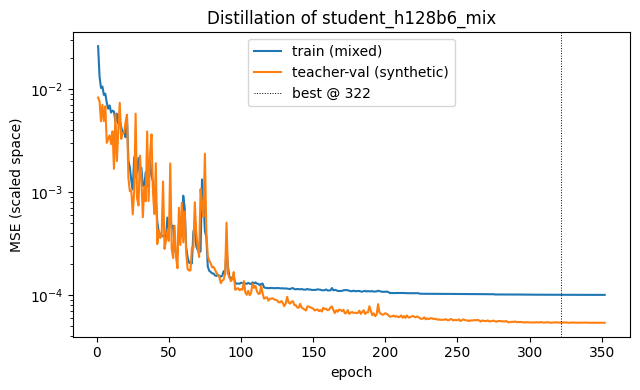

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
e = np.arange(1, len(final_history.train_loss) + 1)
ax.plot(e, final_history.train_loss, label="train (mixed)")
ax.plot(e, final_history.val_loss, label="teacher-val (synthetic)")
ax.axvline(final_history.best_epoch, color="k", lw=0.7, ls=":",
           label=f"best @ {final_history.best_epoch}")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE (scaled space)")
ax.set_title(f"Distillation of {final_name}"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Test evaluation

The single held-out evaluation of the selected model on `test.csv`.

In [11]:
def test_metrics(model):
    pred_full = assemble_full_prediction(
        predict_raw(model, scaled.X_test_s, scaled.Y_transformer, device=device),
        data.X_test)
    per_out = regression_metrics_by_output(data.y_test, pred_full, OUTPUT_COLS)
    return pred_full, per_out


def agg(per_out):
    return {"RMSE": per_out["RMSE"].mean(), "MAE": per_out["MAE"].mean(),
            "R2": per_out["R2"].mean(skipna=True)}


final_pred_full, final_per_out = test_metrics(final_model)
final_agg = agg(final_per_out)

print(f"Improved PINN test: RMSE {final_agg['RMSE']:.5f} | MAE {final_agg['MAE']:.5f} "
      f"| R2 {final_agg['R2']:.6f}")
print("\nPer-output metrics (sorted by RMSE, worst first):")
final_per_out.sort_values("RMSE", ascending=False).round(5)

Improved PINN test: RMSE 0.33477 | MAE 0.23416 | R2 0.998154

Per-output metrics (sorted by RMSE, worst first):


,output,RMSE,MAE,R2
6,n3_total,5.25620,3.69683,0.99947
12,n4_total,0.79019,0.52604,0.99878
2,T_reactor_out,0.26972,0.19743,0.99898
0,Q1_MW,0.01588,0.01155,0.99891
17,MeOH_recovery,0.00781,0.00460,0.99812
16,x_H2O_4,0.00504,0.00299,0.99891
15,x_MeOH_4,0.00504,0.00299,0.99894
18,MeOH_purity_stream4,0.00504,0.00299,0.99894
7,y_CO_3,0.00178,0.00123,0.99921
8,y_H2_3,0.00177,0.00123,0.99922


## 9. Physics diagnostics

Four checks on the test predictions:
1. Closure violation of both streams (should sit at float precision).
2. Recovery bounds: the predicted `MeOH_recovery` must stay inside $[0, 1]$.
3. Regime confusion: on how many rows does the predicted regime (liquid or
   no-liquid) disagree with the truth.
4. The standard all / liquid / no-liquid aggregate breakdown.

In [12]:
vap_viol = float(np.abs(final_pred_full[VAPOR_FRACTION_COLS].sum(axis=1) - 1.0).max())
pred_liq = final_pred_full["n4_total"].values > N4_THRESHOLD
liq_viol = float(np.abs(final_pred_full.loc[pred_liq, LIQUID_FRACTION_COLS].sum(axis=1) - 1.0).max())

# Bound violations are measured like the closure violations: by magnitude, with
# rows counted only beyond float tolerance (the exact-0 no-liquid rows come back
# from the scaler round trip at the 1e-8 level, which is not a real violation).
BOUND_TOL = 1e-6
rec = final_pred_full["MeOH_recovery"].values
rec_overshoot = float(max(rec.max() - 1.0, 0.0))
rec_undershoot = float(max(-rec.min(), 0.0))
rec_oob = int(((rec < -BOUND_TOL) | (rec > 1.0 + BOUND_TOL)).sum())

true_liq = ~data.no_liquid_test.values
false_liquid = int((pred_liq & ~true_liq).sum())
false_no_liquid = int((~pred_liq & true_liq).sum())

print(f"vapor  closure violation max |sum(y)-1| : {vap_viol:.3e}")
print(f"liquid closure violation max |sum(x)-1| : {liq_viol:.3e}  (predicted-liquid rows)")
print(f"recovery bounds: overshoot above 1 = {rec_overshoot:.3e} | "
      f"undershoot below 0 = {rec_undershoot:.3e} | rows beyond {BOUND_TOL:.0e} tolerance: {rec_oob}")
print(f"regime confusion: false-liquid {false_liquid} of {int((~true_liq).sum())} no-liquid rows | "
      f"false-no-liquid {false_no_liquid} of {int(true_liq.sum())} liquid rows")
print()
print(regime_diagnostics(data.y_test, final_pred_full, data.no_liquid_test,
                         columns=OUTPUT_COLS).round(5).to_string(index=False))

vapor  closure violation max |sum(y)-1| : 1.192e-07
liquid closure violation max |sum(x)-1| : 1.788e-07  (predicted-liquid rows)
recovery bounds: overshoot above 1 = 0.000e+00 | undershoot below 0 = 5.960e-08 | rows beyond 1e-06 tolerance: 0
regime confusion: false-liquid 0 of 4 no-liquid rows | false-no-liquid 0 of 1996 liquid rows

         group  rows  mean_RMSE  mean_MAE  mean_R2
      all_rows  2000    0.33477   0.23416  0.99815
   liquid_rows  1996    0.33383   0.23351  0.99812
no_liquid_rows     4    0.65014   0.56124  0.65933


## 10. Comparison with the published models

The earlier neural models are loaded from their live checkpoints and
re-evaluated fresh on the same test set, so every row of the table comes from
the same code path. Elastic Net and XGBoost aggregates are quoted from their
notebooks.

In [13]:
# Residual MLP (raw backbone, no constraints).
_ckr = torch.load("models/task3/residual.pt", map_location="cpu", weights_only=False)
_exr = _ckr["extra"]
resid_prev = ResidualMLP(in_dim=_exr["in_dim"], out_dim=_exr["out_dim"], hidden=_exr["hidden"],
                         n_blocks=_exr["n_blocks"], dropout=_exr["dropout"], hidden_mult=_exr["hidden_mult"])
resid_prev.load_state_dict(_ckr["model_state_dict"])

rows = {
    "Elastic Net (quoted)": {"RMSE": 0.657, "MAE": 0.486, "R2": 0.938},
    "XGBoost (quoted)":     {"RMSE": 0.289, "MAE": 0.224, "R2": 0.987},
    "Residual MLP":                        agg(test_metrics(resid_prev)[1]),
    "PINN (published)":                    agg(test_metrics(pinn_published)[1]),
    "Constrained Deep Ensemble (teacher)": agg(test_metrics(teacher_closed)[1]),
    "Improved PINN (distilled, this notebook)": final_agg,
}
comparison = pd.DataFrame(rows).T.sort_values("R2", ascending=False)
print("Aggregate test comparison (sorted by R2):")
comparison.round(6)

Aggregate test comparison (sorted by R2):


,RMSE,MAE,R2
"Improved PINN (distilled, this notebook)",0.334767,0.234162,0.998154
Constrained Deep Ensemble (teacher),0.349437,0.244076,0.998055
PINN (published),0.338711,0.238235,0.995572
Residual MLP,0.426612,0.290024,0.992132
XGBoost (quoted),0.289000,0.224000,0.987000
Elastic Net (quoted),0.657000,0.486000,0.938000


### 10b. Recovery bounds across models

The same bound check for the published models, which do not have the clamp.
This is the qualitative win of the new layer: for the earlier models staying
inside $[0, 1]$ is a property of the data fit (and it does get violated), for
this model it is a guarantee.

In [14]:
def recovery_stats(pred_full):
    r = pred_full["MeOH_recovery"].values
    return {"min": float(r.min()), "max": float(r.max()),
            "rows > 1": int((r > 1.0 + BOUND_TOL).sum()),
            "rows < 0": int((r < -BOUND_TOL).sum())}

rec_tbl = pd.DataFrame({
    "Residual MLP":                    recovery_stats(test_metrics(resid_prev)[0]),
    "PINN (published)":                recovery_stats(test_metrics(pinn_published)[0]),
    "Ensemble (teacher)":              recovery_stats(test_metrics(teacher_closed)[0]),
    "Improved PINN (with RecoveryClamp)": recovery_stats(final_pred_full),
}).T
print("Predicted MeOH_recovery bounds on the 2000 test rows:")
rec_tbl.round(6)

Predicted MeOH_recovery bounds on the 2000 test rows:


,min,max,rows > 1,rows < 0
Residual MLP,-0.225917,1.003565,2.0,6.0
PINN (published),-0.079350,0.999252,0.0,2.0
Ensemble (teacher),-0.035961,1.000694,1.0,2.0
Improved PINN (with RecoveryClamp),-0.000000,0.998089,0.0,0.0


In [15]:
# Per-output R2 on the outputs that have been the weak spots of every model.
weak = ["y_H2O_3", "Q2_MW", "MeOH_recovery", "x_H2_4", "x_CO_4", "x_MeOH_4"]

def weak_r2(per_out):
    return per_out.set_index("output")["R2"].reindex(weak)

weak_tbl = pd.DataFrame({
    "Residual MLP":       weak_r2(test_metrics(resid_prev)[1]),
    "PINN (published)":   weak_r2(test_metrics(pinn_published)[1]),
    "Ensemble (teacher)": weak_r2(test_metrics(teacher_closed)[1]),
    "Improved PINN":      weak_r2(final_per_out),
}).T
print("Per-output R2 on the historically weak outputs:")
weak_tbl.round(4)

Per-output R2 on the historically weak outputs:


output,y_H2O_3,Q2_MW,MeOH_recovery,x_H2_4,x_CO_4,x_MeOH_4
Residual MLP,0.9962,0.9967,0.9939,0.9583,0.9873,0.9684
PINN (published),0.9972,0.9975,0.9980,0.9742,0.9946,0.9826
Ensemble (teacher),0.9969,0.9976,0.9979,0.9851,0.9989,0.9988
Improved PINN,0.9971,0.9978,0.9981,0.9850,0.9990,0.9989


## 11. Parity plots

Validation-fold predictions (blue, real rows unseen during training) and test
predictions (orange); the no-liquid rows are marked with crosses.

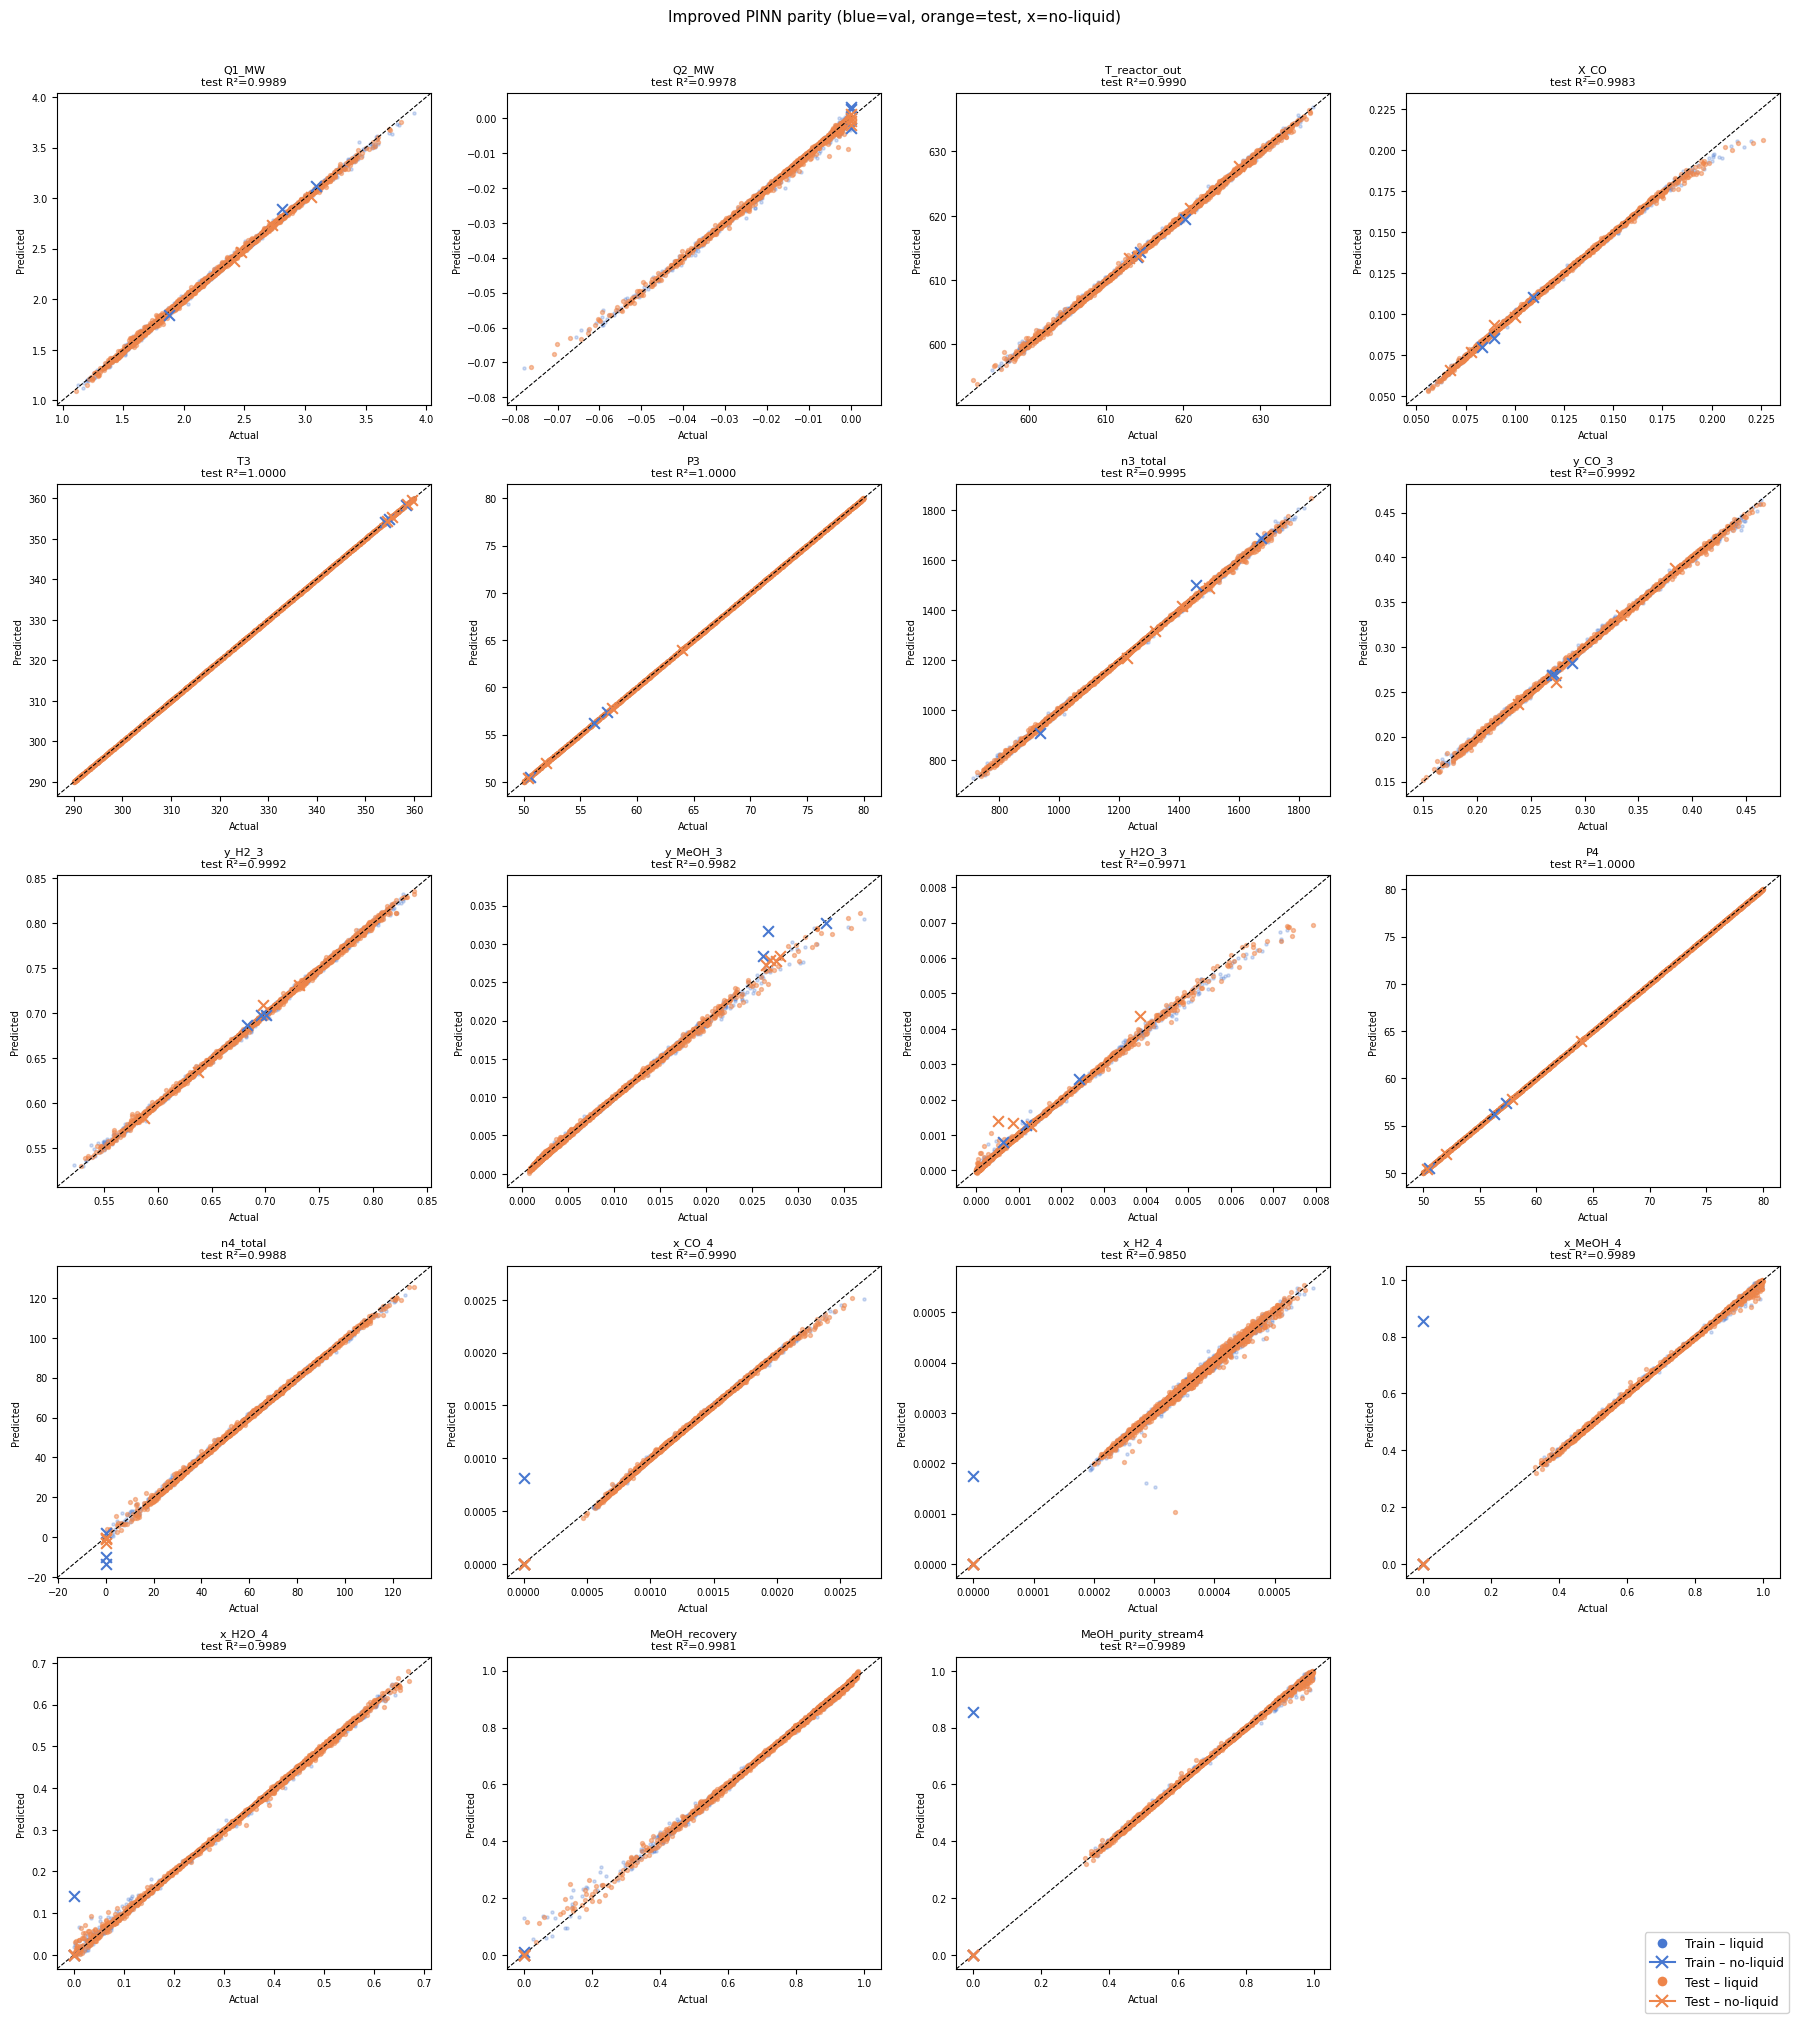

In [16]:
val_pred_modeled = predict_raw(final_model, scaled.X_val_s, scaled.Y_transformer, device=device)
val_pred_full = assemble_full_prediction(val_pred_modeled, data.X_train.iloc[scaled.val_idx])
y_val_true = data.y_train.iloc[scaled.val_idx]
no_liquid_val_series = data.no_liquid_train.iloc[scaled.val_idx]

fig = parity_grid(
    y_train_true=y_val_true, y_train_pred=val_pred_full,
    y_test_true=data.y_test, y_test_pred=final_pred_full,
    no_liquid_train=no_liquid_val_series, no_liquid_test=data.no_liquid_test,
    columns=OUTPUT_COLS,
    title="Improved PINN parity (blue=val, orange=test, x=no-liquid)",
)
plt.show()

## 12. Save the checkpoint and verify the reload

Saved to `models/task3/improved_pinn.pt`; no existing checkpoint is touched.
The `extra` dict carries the backbone constructor args and the distillation
recipe. The reload check rebuilds the model from the saved payload alone and
confirms it reproduces the in-memory test predictions exactly. The model takes
the raw 9 schema inputs; a consumer (for example Task 4) reloads it like
`pinn.pt`, just rebuilding the 4-stage stack (`wrap_pinn_bounded`) with the
constructor args from this payload. With the recovery bounds inside the model,
Task 4's explicit `recovery <= 1` optimizer constraint is no longer needed
when this surrogate is used.

In [17]:
final_model_cpu = final_model.to("cpu")

save_checkpoint(
    "models/task3/improved_pinn.pt", final_model_cpu, scaled, final_history,
    extra={
        "architecture": "PINN_KKT_hard__ResidualMLP_RTDL_backbone__vapor_proj+liquid_closure",
        "reference": "Chen et al., arXiv:2402.07251 (KKT-hPINN); Hinton et al., arXiv:1503.02531 (distillation)",
        "construction": f"distilled from the Constrained Deep Ensemble (pre-closure average) "
                        f"on {N_TRAIN_SYNTH} synthetic + {len(scaled.X_train_s)} real rows; "
                        f"variant {final_name} selected by held-out teacher-val MSE",
        "backbone": "ResidualMLP",
        "in_dim": len(INPUT_COLS), "out_dim": len(MODEL_OUTPUT_COLS),
        "hidden": final_hidden, "n_blocks": final_blocks,
        "dropout": 0.0, "hidden_mult": 2.0,
        "input_features": "raw9", "input_feature_cols": list(INPUT_COLS),
        "stages": "nn.Sequential(ResidualMLP, VaporSumToOneProjection, LiquidClosure, RecoveryClamp)",
        "n4_threshold": N4_THRESHOLD,
        "recovery_bounds": "hard clamp of MeOH_recovery to [0, 1], regime-gated to 0 on no-liquid rows",
        "recovery_max_overshoot": rec_overshoot, "recovery_max_undershoot": rec_undershoot,
        "recovery_oob_rows": rec_oob,
        "teacher": "models/task3/ensemble_pinn.pt (pre-closure ensemble average)",
        "n_synth_train": N_TRAIN_SYNTH, "n_synth_val": N_VAL_SYNTH,
        "mix_real": final_mix, "distill_lr": distill_cfg.lr,
        "weight_decay": distill_cfg.weight_decay, "random_state": RANDOM_STATE,
        "distill_results": d_rows,
        "test_agg": final_agg,
        "vapor_violation_max": vap_viol, "liquid_violation_max": liq_viol,
    },
)
print("Saved models/task3/improved_pinn.pt")

Saved models/task3/improved_pinn.pt


In [18]:
# Reload check: rebuild from the payload alone and compare predictions.
ck = torch.load("models/task3/improved_pinn.pt", map_location="cpu", weights_only=False)
ex = ck["extra"]
bb_new = ResidualMLP(in_dim=ex["in_dim"], out_dim=ex["out_dim"], hidden=ex["hidden"],
                     n_blocks=ex["n_blocks"], dropout=ex["dropout"], hidden_mult=ex["hidden_mult"])
model_new = wrap_pinn_bounded(bb_new)
model_new.load_state_dict(ck["model_state_dict"])

pred_new = assemble_full_prediction(
    predict_raw(model_new, scaled.X_test_s, scaled.Y_transformer, device="cpu"),
    data.X_test)
per_out_new = regression_metrics_by_output(data.y_test, pred_new, OUTPUT_COLS)
print(f"reloaded test R2 = {per_out_new['R2'].mean(skipna=True):.6f} | "
      f"in-memory test R2 = {final_agg['R2']:.6f}")
assert np.allclose(pred_new.values,
                   assemble_full_prediction(
                       predict_raw(final_model_cpu, scaled.X_test_s,
                                   scaled.Y_transformer, device="cpu"),
                       data.X_test).values)
print("Reload reproduces the in-memory predictions exactly.")

reloaded test R2 = 0.998154 | in-memory test R2 = 0.998154
Reload reproduces the in-memory predictions exactly.


## 13. Summary

The frozen Constrained Deep Ensemble labelled 150k synthetic operating points;
a single student network trained on them (plus the real rows) matches the
ensemble almost exactly and inherits its accuracy, at one fifth of the
inference cost and in one clean checkpoint. Two design points made it work:
distilling the smooth pre-closure ensemble average instead of the gated output,
and early-stopping on a held-out teacher-labelled set.

The student carries three hard constraint layers. The two closure layers keep
both composition sums at float precision, and the new `RecoveryClamp` keeps
the predicted methanol recovery inside its physical bounds: for every earlier
model the $[0, 1]$ bound was only a property of the data fit (and the test set
shows violations), for this model it is a guarantee, and Task 4's explicit
recovery cap becomes unnecessary with this surrogate. Test metrics, physics
diagnostics, and the comparison against the published models are in sections
8 to 10.

Checkpoint: `models/task3/improved_pinn.pt`, reload verified. The ensemble
remains the deployed Task 4 surrogate; this notebook shows its accuracy
survives compression into a single small PINN.